In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.datasets import fetch_openml
from torch.utils.data import TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import random

In [5]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X = mnist.data.astype(np.float32) / 255.0       # scale pixels to [0, 1]
y = mnist.target.astype(np.int64)

X = X.reshape(-1, 1, 28, 28)

X = (X - 0.1307) / 0.3081

X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)

X_train, X_test = X_tensor[:60000], X_tensor[60000:]
y_train, y_test = y_tensor[:60000], y_tensor[60000:]

mnist_train = TensorDataset(X_train, y_train)
mnist_test  = TensorDataset(X_test,  y_test)

print(f"Train size: {len(mnist_train)}")   # 60000
print(f"Test size:  {len(mnist_test)}")    # 10000

Train size: 60000
Test size:  10000


In [6]:
class SiameseMNIST(Dataset):
    def __init__(self, mnist_dataset):
        self.dataset = mnist_dataset
        
        self.label_to_indices = {}
        for idx, (_, label) in enumerate(self.dataset):
            label = int(label)
            if label not in self.label_to_indices:
                self.label_to_indices[label] = []
            self.label_to_indices[label].append(idx)
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        should_get_same = random.randint(0, 1)
        
        img1, label1 = self.dataset[index]
        
        if should_get_same:
            same_indices = self.label_to_indices[int(label1)]
            idx2 = random.choice(same_indices)
            img2, _ = self.dataset[idx2]
            pair_label = torch.tensor(1, dtype=torch.float32)
        else:
            all_labels = list(self.label_to_indices.keys())
            different_label = random.choice([l for l in all_labels if l != int(label1)])
            idx2 = random.choice(self.label_to_indices[different_label])
            img2, _ = self.dataset[idx2]
            pair_label = torch.tensor(0, dtype=torch.float32)
        
        return img1, img2, pair_label

In [7]:
train_dataset = SiameseMNIST(mnist_train)
img1, img2, label = train_dataset[0]

print("Image 1 shape:", img1.shape)
print("Image 2 shape:", img2.shape)
print("Pair label:", label)

Image 1 shape: torch.Size([1, 28, 28])
Image 2 shape: torch.Size([1, 28, 28])
Pair label: tensor(1.)


In [9]:
class CNNBackbone(nn.Module):
    def __init__(self):
        super(CNNBackbone, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),


            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.embedding(x)
        return x

In [10]:
backbone = CNNBackbone()

# Create a fake batch of 4 images to test
dummy_input = torch.randn(4, 1, 28, 28)
output = backbone(dummy_input)

print("Input shape: ", dummy_input.shape)
print("Embedding shape:", output.shape)  # Should be [4, 128]

Input shape:  torch.Size([4, 1, 28, 28])
Embedding shape: torch.Size([4, 128])


In [11]:
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.backbone = CNNBackbone()
    
    def forward(self, img1, img2):
        embedding1 = self.backbone(img1)
        embedding2 = self.backbone(img2)
        
        distance = torch.nn.functional.pairwise_distance(embedding1, embedding2)
        return distance

In [13]:
model = SiameseNetwork()

dummy_img1 = torch.randn(4, 1, 28, 28)
dummy_img2 = torch.randn(4, 1, 28, 28)

distances = model(dummy_img1, dummy_img2)

print("Distance shape:", distances.shape)   # Should be [4]
print("Distances:", distances)              # 4 random distance values

Distance shape: torch.Size([4])
Distances: tensor([0.4005, 0.3953, 0.4917, 0.5100], grad_fn=<NormBackward1>)


In [14]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin
    
    def forward(self, distance, label):
        same_pair_loss      = label * distance.pow(2)
        different_pair_loss = (1 - label) * torch.clamp(self.margin - distance, min=0).pow(2)
        loss = (same_pair_loss + different_pair_loss).mean()
        return loss

In [15]:
criterion = ContrastiveLoss(margin=1.0)

# Simulate a batch: 4 pairs, some same some different
fake_distances = torch.tensor([0.2, 0.8, 0.1, 0.9])
fake_labels    = torch.tensor([1.0, 0.0, 1.0, 0.0])

loss = criterion(fake_distances, fake_labels)
print("Loss:", loss.item())

Loss: 0.02500000037252903


In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Training on:", device)

model     = SiameseNetwork().to(device)
criterion = ContrastiveLoss(margin=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_dataset = SiameseMNIST(mnist_train)
test_dataset  = SiameseMNIST(mnist_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

Training on: cpu


In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for batch_idx, (img1, img2, labels) in enumerate(loader):
        img1   = img1.to(device)
        img2   = img2.to(device)
        labels = labels.to(device)

        distances = model(img1, img2)
        loss      = criterion(distances, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    return avg_loss

In [20]:
EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    print(f"Epoch {epoch+1}/{EPOCHS}  |  Loss: {train_loss:.4f}")

Epoch 1/5  |  Loss: 0.0496
Epoch 2/5  |  Loss: 0.0247
Epoch 3/5  |  Loss: 0.0194
Epoch 4/5  |  Loss: 0.0157
Epoch 5/5  |  Loss: 0.0132


In [21]:
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss    = 0
    correct       = 0
    total         = 0

    with torch.no_grad():
        for img1, img2, labels in loader:
            img1   = img1.to(device)
            img2   = img2.to(device)
            labels = labels.to(device)

            distances = model(img1, img2)
            loss      = criterion(distances, labels)
            total_loss += loss.item()

            predictions = (distances < threshold).float()
            correct     += (predictions == labels).sum().item()
            total       += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total * 100
    return avg_loss, accuracy

In [22]:
train_loss, train_acc = evaluate(model, train_loader, criterion, device)
test_loss,  test_acc  = evaluate(model, test_loader,  criterion,  device)

print(f"Train  |  Loss: {train_loss:.4f}  |  Accuracy: {train_acc:.2f}%")
print(f"Test   |  Loss: {test_loss:.4f}  |  Accuracy: {test_acc:.2f}%")

Train  |  Loss: 0.0116  |  Accuracy: 99.32%
Test   |  Loss: 0.0149  |  Accuracy: 98.83%


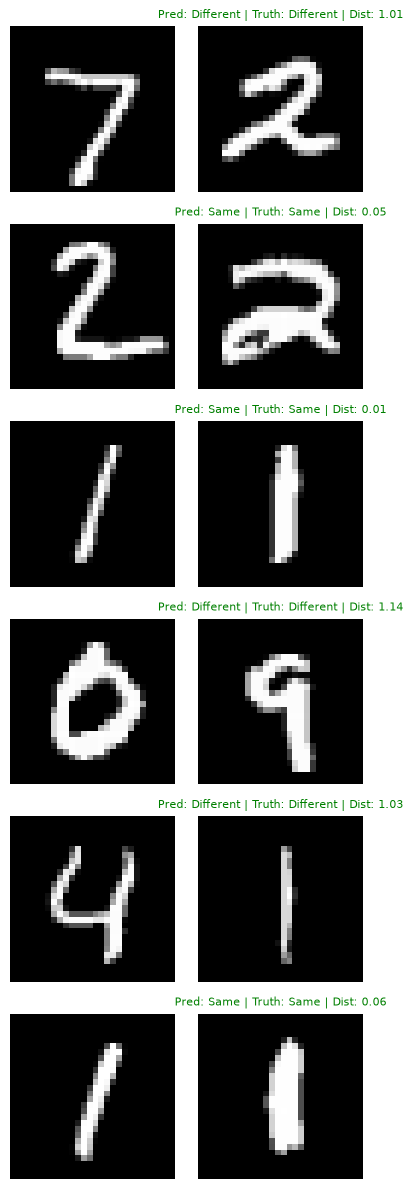

In [23]:
def visualize_predictions(model, dataset, device, threshold=0.5, num_pairs=6):
    model.eval()
    fig, axes = plt.subplots(num_pairs, 2, figsize=(4, num_pairs * 2))

    with torch.no_grad():
        for i in range(num_pairs):
            img1, img2, true_label = dataset[i]

            # Add batch dimension: [1, 28, 28] → [1, 1, 28, 28]
            dist = model(
                img1.unsqueeze(0).to(device),
                img2.unsqueeze(0).to(device)
            )

            pred  = "Same" if dist.item() < threshold else "Different"
            truth = "Same" if true_label.item() == 1  else "Different"
            color = "green" if pred == truth else "red"

            axes[i, 0].imshow(img1.squeeze(), cmap='gray')
            axes[i, 0].axis('off')
            axes[i, 1].imshow(img2.squeeze(), cmap='gray')
            axes[i, 1].axis('off')
            axes[i, 1].set_title(
                f"Pred: {pred} | Truth: {truth} | Dist: {dist.item():.2f}",
                color=color, fontsize=8
            )

    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_dataset, device)